In [23]:
import os 
# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)

import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt # import matplotlib to visualize our qc metrics

# magic incantation to help matplotlib work with our jupyter notebook
%matplotlib inline 

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis/tabula_muris_brain/low_dimensional_rep
scanpy==1.9.3 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.1 pandas==1.5.3 scikit-learn==1.0.1 statsmodels==0.13.1 python-igraph==0.10.4 pynndescent==0.5.8


In [24]:
import sys
sys.path.append('../../utils')
from functions import * 

In [25]:
# Metadata file:
metadata_file = '/gpfs/commons/groups/knowles_lab/data/tabula_muris/smart_seq/d8a0c006-2991-5ddb-8ed8-7b7e8c187fe3/all_tabula_muris_samples_w_celltype_column.txt'
metadata = pd.read_csv(metadata_file, sep='\t', index_col=0)
print("Loaded metadata file!")
print_separator()

organ = 'Marrow'

# Subset the metadata file to only include the organ of interest:
metadata = metadata[metadata['tissue'].str.contains(organ)]
print("The number of cells in the metadata corresponding to the organ of interest is: " + str(len(metadata.index)))
print_separator()

Loaded metadata file!
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The number of cells in the metadata corresponding to the organ of interest is: 5037
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


In [26]:
# load PCA and UMAP representations of brain data using gene counts 
PCA_rep = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisMarrow/scanpy_pca_embedding.csv')
UMAP_rep = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisMarrow/scanpy_umap_embedding.csv')

#Leaflet_rep = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/Leaflet_BBmixture.csv')
Leaflet_rep = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisMarrow/Leaflet_BBmixture.csv')

In [27]:
UMAP_rep.drop(columns=['Unnamed: 0'], inplace=True)
UMAP_rep.head()

,UMAP_0,UMAP_1,cell_id,cell_type
0,13.444532,3.989610,A12-D042193-3_8_M-1-1,naive B cell
1,14.838902,3.550225,A12-MAA000844-3_10_M-1-1,naive B cell
2,17.267141,2.498254,A12-MAA001884-3_38_F-1-1,naive B cell
3,13.361399,2.570704,A14-D042044-3_9_M-1-1,naive B cell
4,13.284236,3.210345,A14-D042193-3_8_M-1-1,naive B cell


In [28]:
Leaflet_rep.drop(columns=['Unnamed: 0'], inplace=True)
Leaflet_rep.drop(columns=['cell_type'], inplace=True)
Leaflet_rep.head()

,CellState_0,CellState_1,CellState_2,CellState_3,CellState_4,CellState_5,CellState_6,CellState_7,CellState_8,CellState_9,...,CellState_13,CellState_14,CellState_15,CellState_16,CellState_17,CellState_18,CellState_19,CellState_20,CellState_21,cell_id
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,A1-D041912-3_8_M-1-1
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,A1-MAA000409-3_10_M-1-1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,A1-MAA000596-3_9_M-1-1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,A1-MAA000600-3_8_M-1-1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,A1-MAA000652-3_10_M-1-1


In [29]:
# combine UMAP and BB mixture results
UMAP_rep = UMAP_rep.merge(Leaflet_rep, on='cell_id', how='left')

In [30]:
UMAP_rep.cell_type.unique()

array(['naive B cell', 'monocyte', 'regulatory T cell', 'B cell',
       'immature T cell', 'immature B cell', 'common lymphoid progenitor',
       'megakaryocyte-erythroid progenitor cell',
       'mature natural killer cell', 'immature natural killer cell',
       'basophil', 'macrophage', 'pre-natural killer cell', 'granulocyte',
       'immature NK T cell', 'granulocyte monocyte progenitor cell',
       'precursor B cell', 'Slamf1-positive multipotent progenitor cell',
       'granulocytopoietic cell', 'late pro-B cell',
       'Slamf1-negative multipotent progenitor cell',
       'hematopoietic precursor cell'], dtype=object)

In [31]:
UMAP_rep.head()

,UMAP_0,UMAP_1,cell_id,cell_type,CellState_0,CellState_1,CellState_2,CellState_3,CellState_4,CellState_5,...,CellState_12,CellState_13,CellState_14,CellState_15,CellState_16,CellState_17,CellState_18,CellState_19,CellState_20,CellState_21
0,13.444532,3.989610,A12-D042193-3_8_M-1-1,naive B cell,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,14.838902,3.550225,A12-MAA000844-3_10_M-1-1,naive B cell,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,17.267141,2.498254,A12-MAA001884-3_38_F-1-1,naive B cell,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,13.361399,2.570704,A14-D042044-3_9_M-1-1,naive B cell,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,13.284236,3.210345,A14-D042193-3_8_M-1-1,naive B cell,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


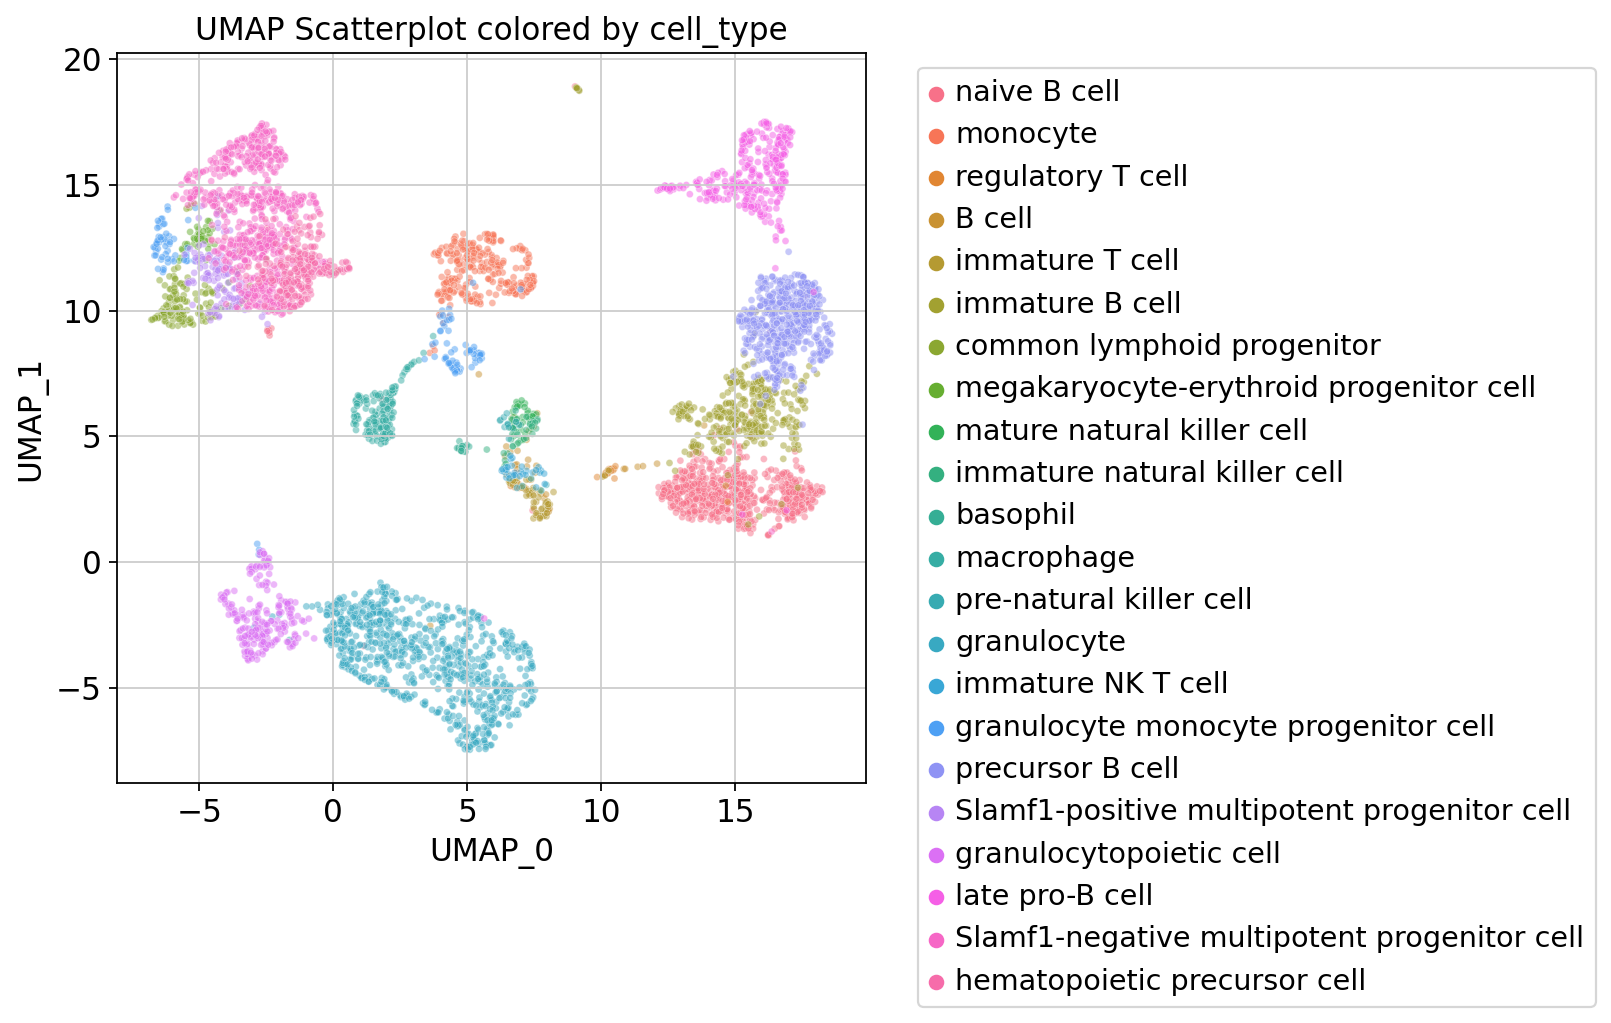

In [32]:
# make scatter plot where x-axis is UMAP_0 and y-axis is UMAP_1
# make colours the cell_type groups in UMAP_rep

# Scatterplot colored by 'cell_type'
plt.figure(figsize=(6, 6))
sns.scatterplot(x=UMAP_rep["UMAP_0"], y=UMAP_rep["UMAP_1"], hue=UMAP_rep['cell_type'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('UMAP Scatterplot colored by cell_type')
plt.show()


In [38]:
UMAP_rep.cell_type.unique()

array(['naive B cell', 'monocyte', 'regulatory T cell', 'B cell',
       'immature T cell', 'immature B cell', 'common lymphoid progenitor',
       'megakaryocyte-erythroid progenitor cell',
       'mature natural killer cell', 'immature natural killer cell',
       'basophil', 'macrophage', 'pre-natural killer cell', 'granulocyte',
       'immature NK T cell', 'granulocyte monocyte progenitor cell',
       'precursor B cell', 'Slamf1-positive multipotent progenitor cell',
       'granulocytopoietic cell', 'late pro-B cell',
       'Slamf1-negative multipotent progenitor cell',
       'hematopoietic precursor cell'], dtype=object)

In [33]:
# figure out which CellState has a value of 1 and assign that cell state number of the cell 
# find columns that have CellState in them?
cellstates = [col for col in UMAP_rep.columns if 'CellState' in col]
UMAP_rep["cellassignment"] = UMAP_rep[cellstates].idxmax(axis=1)

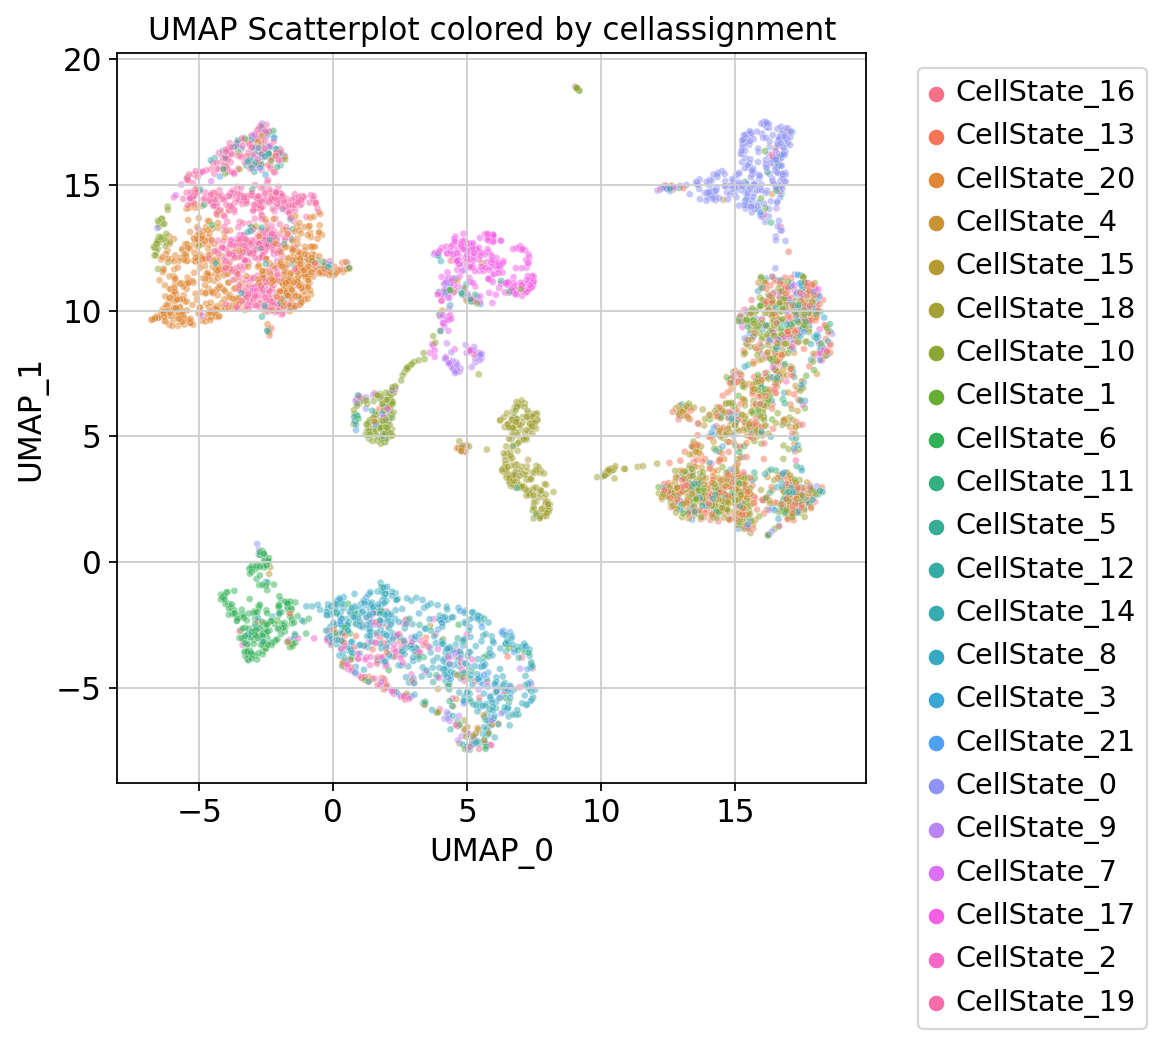

In [34]:
# Scatterplot colored by 'cell_state'
plt.figure(figsize=(6, 6))
sns.scatterplot(x=UMAP_rep["UMAP_0"], y=UMAP_rep["UMAP_1"], hue=UMAP_rep['cellassignment'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('UMAP Scatterplot colored by cellassignment')
plt.show()


In [39]:
UMAP_rep[UMAP_rep["cell_type"] == 'naive B cell']

,UMAP_0,UMAP_1,cell_id,cell_type,CellState_0,CellState_1,CellState_2,CellState_3,CellState_4,CellState_5,...,CellState_13,CellState_14,CellState_15,CellState_16,CellState_17,CellState_18,CellState_19,CellState_20,CellState_21,cellassignment
0,13.444532,3.989610,A12-D042193-3_8_M-1-1,naive B cell,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,CellState_16
1,14.838902,3.550225,A12-MAA000844-3_10_M-1-1,naive B cell,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CellState_13
2,17.267141,2.498254,A12-MAA001884-3_38_F-1-1,naive B cell,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CellState_13
3,13.361399,2.570704,A14-D042044-3_9_M-1-1,naive B cell,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,CellState_20
4,13.284236,3.210345,A14-D042193-3_8_M-1-1,naive B cell,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CellState_4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
682,15.548432,1.908110,P7-D042044-3_9_M-1-1,naive B cell,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,CellState_18
683,15.184843,2.222320,P7-MAA000844-3_10_M-1-1,naive B cell,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CellState_12
684,15.041862,3.718649,P8-D041912-3_8_M-1-1,naive B cell,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,CellState_15
685,17.132425,1.929337,P8-MAA001884-3_38_F-1-1,naive B cell,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,CellState_20


In [45]:
UMAP_rep[UMAP_rep["cell_type"] == 'naive B cell'].groupby("cellassignment")["cell_type"].value_counts().sort_values(ascending=False)

cellassignment  cell_type   
CellState_13    naive B cell    146
CellState_4     naive B cell    103
CellState_18    naive B cell     85
CellState_10    naive B cell     75
CellState_1     naive B cell     47
CellState_15    naive B cell     37
CellState_20    naive B cell     29
CellState_11    naive B cell     28
CellState_16    naive B cell     26
CellState_12    naive B cell     20
CellState_8     naive B cell     15
CellState_21    naive B cell     15
CellState_5     naive B cell     12
CellState_14    naive B cell     11
CellState_6     naive B cell     10
CellState_7     naive B cell      6
CellState_3     naive B cell      6
CellState_0     naive B cell      5
CellState_17    naive B cell      5
CellState_9     naive B cell      3
CellState_2     naive B cell      2
CellState_19    naive B cell      1
Name: cell_type, dtype: int64

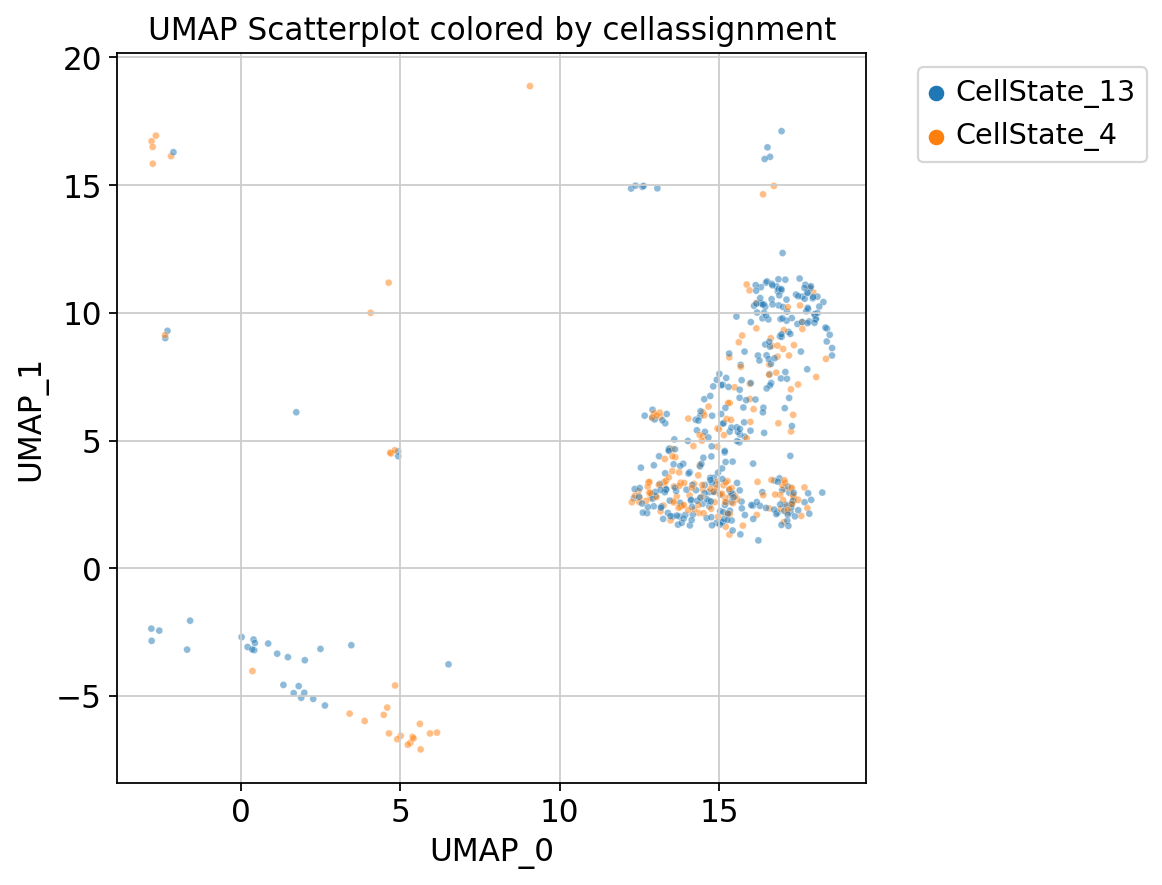

In [50]:
# Scatterplot colored by 'cell_state' but just show cell states 4 and 13 
plt.figure(figsize=(6, 6))
filt_dat=UMAP_rep[(UMAP_rep['cellassignment'] == "CellState_13") | (UMAP_rep['cellassignment'] == "CellState_4")]
sns.scatterplot(x=filt_dat["UMAP_0"], y=filt_dat["UMAP_1"], hue=filt_dat['cellassignment'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('UMAP Scatterplot colored by cellassignment')
plt.show()

In [ ]:
# Scatterplot colored by 'cell_state' but just show cell states 4 and 13 
plt.figure(figsize=(6, 6))
filt_dat=UMAP_rep[(UMAP_rep['cell_type'] == "naive B cell")]
sns.scatterplot(x=filt_dat["UMAP_0"], y=filt_dat["UMAP_1"], hue=filt_dat['cell_type'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('UMAP Scatterplot colored by cellassignment')
plt.show()

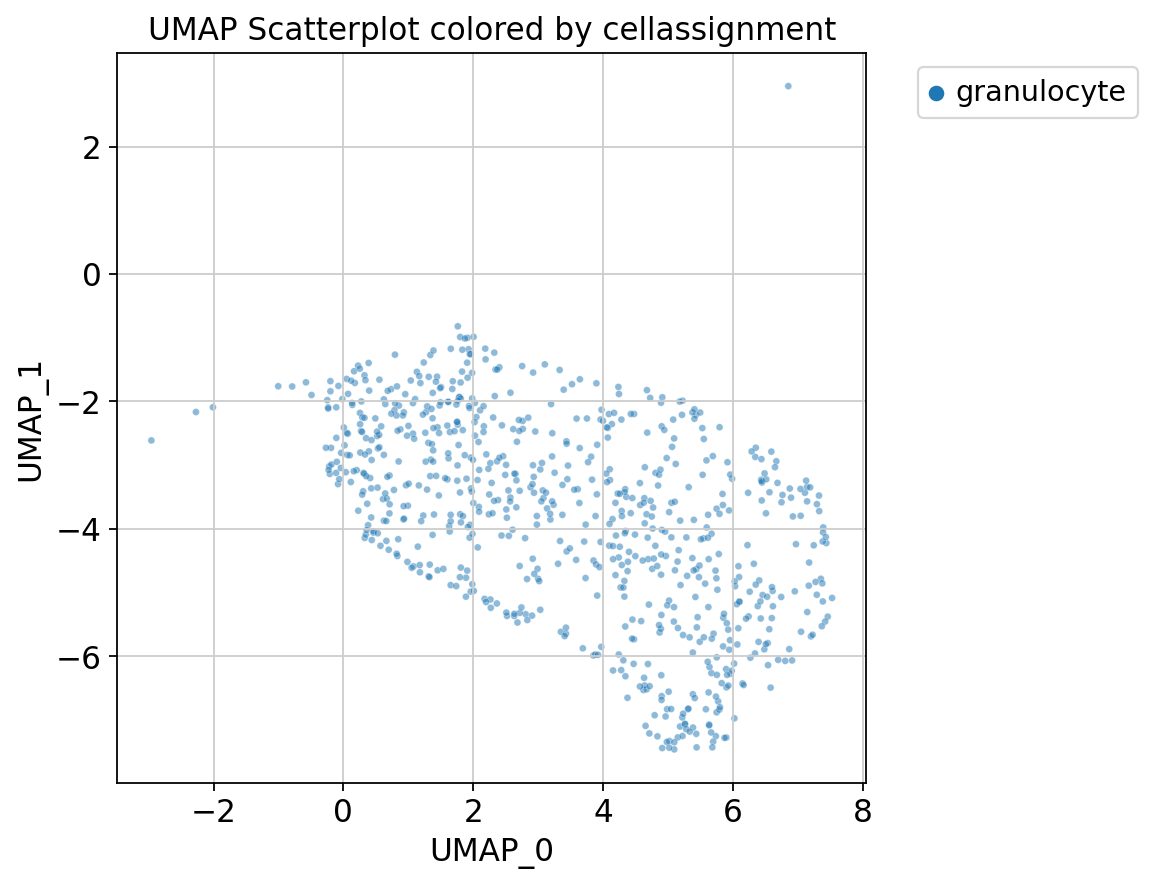

In [53]:
# Scatterplot colored by 'cell_state' but just show cell states 4 and 13 
plt.figure(figsize=(6, 6))
filt_dat=UMAP_rep[(UMAP_rep['cell_type'] == "granulocyte")]
sns.scatterplot(x=filt_dat["UMAP_0"], y=filt_dat["UMAP_1"], hue=filt_dat['cell_type'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('UMAP Scatterplot colored by cellassignment')
plt.show()

In [54]:
UMAP_rep[UMAP_rep["cell_type"] == 'granulocyte'].groupby("cellassignment")["cell_type"].value_counts().sort_values(ascending=False)

cellassignment  cell_type  
CellState_8     granulocyte    427
CellState_2     granulocyte     72
CellState_16    granulocyte     47
CellState_9     granulocyte     29
CellState_12    granulocyte     26
CellState_21    granulocyte     24
CellState_5     granulocyte     22
CellState_11    granulocyte     21
CellState_13    granulocyte     19
CellState_4     granulocyte     17
CellState_6     granulocyte     12
CellState_1     granulocyte     10
CellState_18    granulocyte      8
CellState_14    granulocyte      4
CellState_15    granulocyte      4
CellState_7     granulocyte      4
CellState_3     granulocyte      4
CellState_0     granulocyte      2
CellState_17    granulocyte      2
CellState_19    granulocyte      2
Name: cell_type, dtype: int64

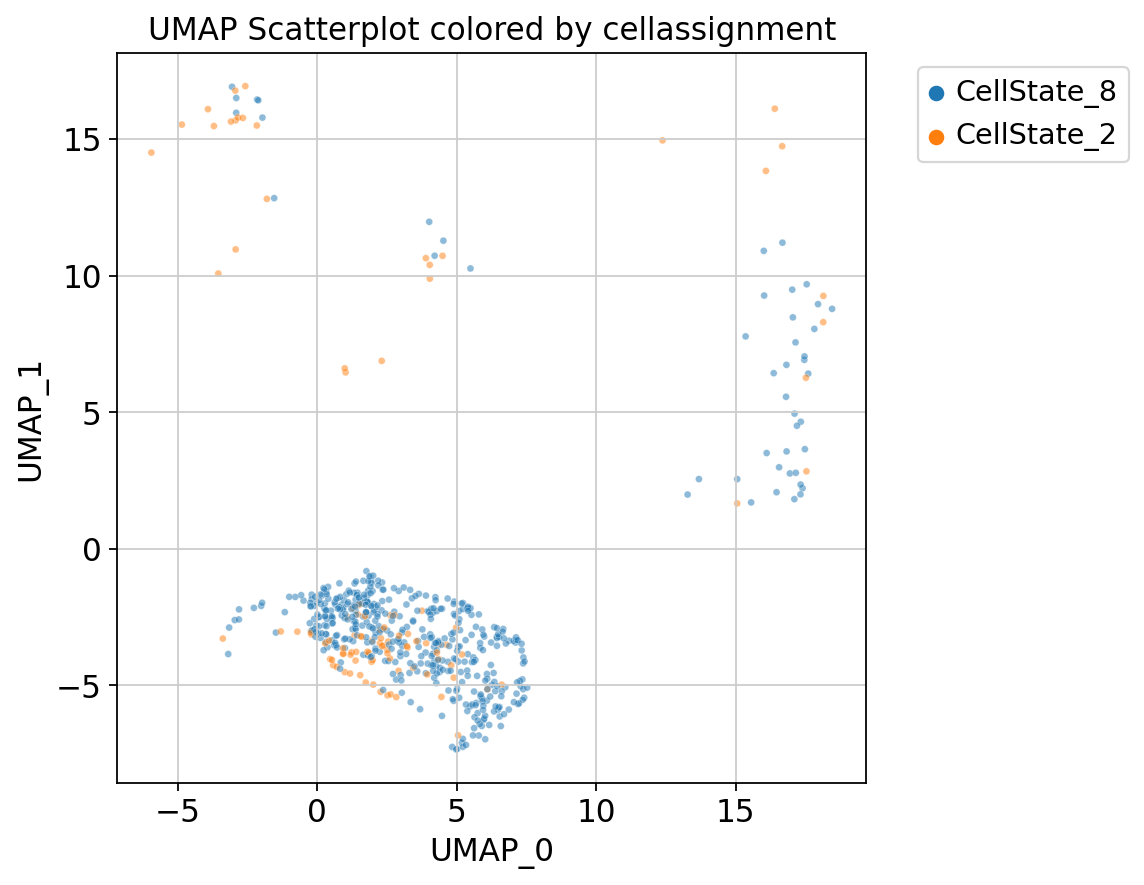

In [55]:
# Scatterplot colored by 'cell_state' but just show cell states 4 and 13 
plt.figure(figsize=(6, 6))
filt_dat=UMAP_rep[(UMAP_rep['cellassignment'] == "CellState_8") | (UMAP_rep['cellassignment'] == "CellState_2")]
sns.scatterplot(x=filt_dat["UMAP_0"], y=filt_dat["UMAP_1"], hue=filt_dat['cellassignment'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('UMAP Scatterplot colored by cellassignment')
plt.show()